In [20]:
import os
import csv
import random
from datetime import datetime
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models

In [21]:
import sys
import torch

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Python: d:\Sir. YKT_AIE\Myanmar-HandWritting-Dataset-Project\.venv\Scripts\python.exe
Torch: 2.11.0+cu128
CUDA available: True
Torch CUDA version: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060
Current device: 0
Using device: cuda


In [22]:
import sys
print(sys.executable)

d:\Sir. YKT_AIE\Myanmar-HandWritting-Dataset-Project\.venv\Scripts\python.exe


In [ ]:
DATASET_ROOT = "time/Thiri_Shin_Thant"
MAX_CLASSES = 200
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
VAL_SAMPLES_PER_CLASS = 1
TEST_SAMPLES_PER_CLASS = 0
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
INPUT_CHANNELS = 1
EARLY_STOPPING_PATIENCE = 3
RESUME_FROM_CHECKPOINT = False
VIS_SAMPLES = 10
LOG_DIR = Path("experiment_logs")
MODEL_DIR = Path("checkpoints")
CLASS_DISPLAY_DECIMALS = 4
MODEL_TYPE = "cnn"

In [24]:
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [25]:
class MyanmarHandwritingDataset(Dataset):
    def __init__(self, root, transform=None, max_classes=None):
        self.root = Path(root)
        self.transform = transform

        self.image_paths = sorted([
            p for p in self.root.glob("*.png")
        ])

        if len(self.image_paths) == 0:
            raise ValueError(f"No PNG images found in {self.root}")

        samples = []
        bad_files = []

        for p in self.image_paths:
            try:
                # filename format: label-sample.png  ->  12-3.png
                label_text = p.stem.split("-")[0]

                # sanity check image can open
                with Image.open(p) as img:
                    img.verify()

                samples.append((p, label_text))
            except Exception as e:
                bad_files.append((p, str(e)))

        self.bad_files = bad_files

        all_labels = sorted(set(label for _, label in samples), key=lambda x: int(x))

        if max_classes is not None:
            selected = set(all_labels[:max_classes])
            samples = [(p, y) for (p, y) in samples if y in selected]
            all_labels = sorted(selected, key=lambda x: int(x))

        self.label2idx = {label: idx for idx, label in enumerate(all_labels)}
        self.idx2label = {idx: label for label, idx in self.label2idx.items()}

        self.samples = [(p, self.label2idx[label]) for p, label in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

Dataset checking

In [26]:
root = Path(DATASET_ROOT)
print("Dataset exists:", root.exists())
print("First 20 files:")

all_pngs = sorted(root.glob("*.png"))
for p in all_pngs[:20]:
    print(p.name)

Dataset exists: True
First 20 files:
1-1.png
1-2.png
1-3.png
10-1.png
10-2.png
10-3.png
100-1.png
100-2.png
100-3.png
1000-1.png
1000-2.png
1000-3.png
1001-1.png
1001-2.png
1001-3.png
1001-4.png
1002-1.png
1002-2.png
1002-3.png
1003-1.png


Check labels, class counts, image sizes

In [27]:
label_counter = Counter()
sizes = []
bad_files = []

for p in all_pngs:
    try:
        label = p.stem.split("-")[0]
        label_counter[label] += 1

        with Image.open(p) as img:
            sizes.append(img.size)
    except (UnidentifiedImageError, OSError, IOError) as e:
        bad_files.append((str(p), str(e)))

print("Total images found:", len(all_pngs))
print("Total classes found:", len(label_counter))
print("Bad/corrupted files:", len(bad_files))
print("Most common image sizes:", Counter(sizes).most_common(5))

counts = list(label_counter.values())
print("Min samples/class:", min(counts))
print("Max samples/class:", max(counts))
print("Mean samples/class:", np.mean(counts))
print("Median samples/class:", np.median(counts))

print("\nFirst 20 class counts:")
for i, (k, v) in enumerate(sorted(label_counter.items(), key=lambda x: int(x[0]))):
    if i >= 20:
        break
    print(k, v)

Total images found: 13343
Total classes found: 4413
Bad/corrupted files: 0
Most common image sizes: [((128, 128), 13343)]
Min samples/class: 3
Max samples/class: 5
Mean samples/class: 3.023566734647632
Median samples/class: 3.0

First 20 class counts:
1 3
2 3
3 3
4 3
5 3
6 3
7 3
8 3
9 3
10 3
11 3
12 3
13 3
14 3
15 3
16 3
17 3
18 3
19 3
20 4


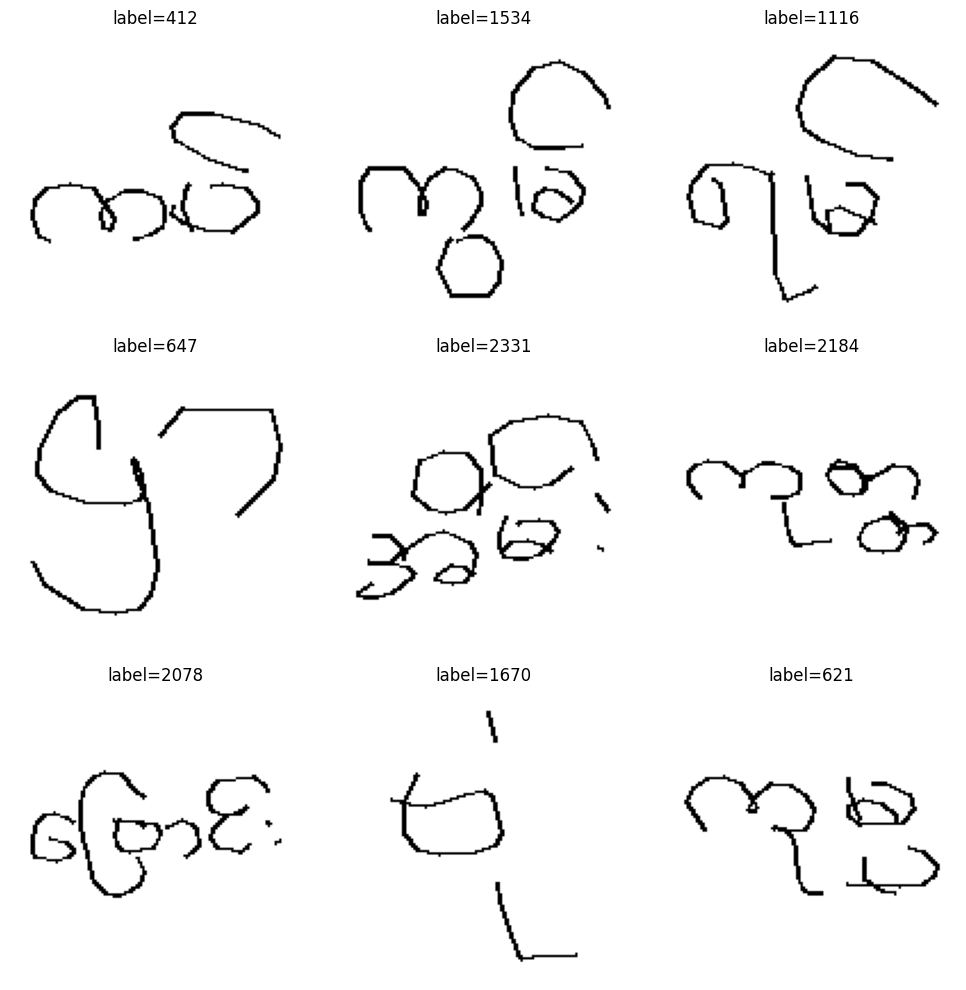

In [28]:
def show_random_images(root_dir, n=9):
    root_dir = Path(root_dir)
    files = sorted(root_dir.glob("*.png"))
    chosen = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(10, 10))
    for i, path in enumerate(chosen, 1):
        img = Image.open(path).convert("RGB")
        label = path.stem.split("-")[0]

        plt.subplot(int(np.ceil(n/3)), 3, i)
        plt.imshow(img)
        plt.title(f"label={label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(DATASET_ROOT, n=9)

Transforms

For all three folders, use RGB first.
That keeps stroke/time color information.

In [29]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=INPUT_CHANNELS),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * INPUT_CHANNELS, std=[0.5] * INPUT_CHANNELS),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=INPUT_CHANNELS),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * INPUT_CHANNELS, std=[0.5] * INPUT_CHANNELS),
])

Build dataset

In [30]:
full_dataset_for_info = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=val_transform,
    max_classes=MAX_CLASSES
)

print("Total samples:", len(full_dataset_for_info))
print("Total classes:", len(full_dataset_for_info.label2idx))
print("First 20 labels:", list(full_dataset_for_info.label2idx.keys())[:20])
print("Bad files inside dataset object:", len(full_dataset_for_info.bad_files))

Total samples: 612
Total classes: 200
First 20 labels: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
Bad files inside dataset object: 0


In [31]:
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

def split_by_class(dataset, val_per_class=1, test_per_class=0, seed=42):
    rng = random.Random(seed)
    class_to_indices = defaultdict(list)

    for idx, (_, label) in enumerate(dataset.samples):
        class_to_indices[label].append(idx)

    train_indices = []
    val_indices = []
    test_indices = []

    for label, indices in class_to_indices.items():
        rng.shuffle(indices)

        n_total = len(indices)
        n_test = min(test_per_class, max(0, n_total - 1))
        n_remaining = n_total - n_test
        n_val = min(val_per_class, max(0, n_remaining - 1))

        test_indices.extend(indices[:n_test])
        val_indices.extend(indices[n_test:n_test + n_val])
        train_indices.extend(indices[n_test + n_val:])

    return train_indices, val_indices, test_indices


base_dataset = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=val_transform,
    max_classes=MAX_CLASSES
)

train_dataset = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=train_transform,
    max_classes=MAX_CLASSES
)

val_dataset = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=val_transform,
    max_classes=MAX_CLASSES
)

train_indices, val_indices, test_indices = split_by_class(
    base_dataset,
    val_per_class=VAL_SAMPLES_PER_CLASS,
    test_per_class=TEST_SAMPLES_PER_CLASS,
    seed=SEED,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)
test_subset = Subset(val_dataset, test_indices)

if len(train_subset) == 0 or len(val_subset) == 0:
    raise ValueError("Empty train/val split. Check MAX_CLASSES, VAL_SAMPLES_PER_CLASS, and TEST_SAMPLES_PER_CLASS.")

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = None
if len(test_subset) > 0:
    test_loader = DataLoader(
        test_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

num_classes = len(train_dataset.label2idx)

print("Train samples:", len(train_subset))
print("Val samples:", len(val_subset))
print("Test samples:", len(test_subset))
print("Num classes:", num_classes)
print("Workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Train samples: 412
Val samples: 200
Num classes: 200
Workers: 2
Pin memory: True


CNN

In [32]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, img_size=64, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        final_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * final_size * final_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Build model

In [33]:
model = SimpleCNN(num_classes=num_classes, img_size=IMG_SIZE, in_channels=INPUT_CHANNELS).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

start_epoch = 0
best_val_acc = 0.0
MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path = MODEL_DIR / f"best_{Path(DATASET_ROOT).parts[0]}_{MODEL_TYPE}_{MAX_CLASSES}.pth"

if RESUME_FROM_CHECKPOINT and Path(best_model_path).exists():
    saved = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(saved["model_state_dict"])
    best_val_acc = saved.get("best_val_acc", 0.0)
    start_epoch = saved.get("epoch", 0)
    print(f"Resumed from {best_model_path} at epoch {start_epoch}")

print(model.__class__.__name__)

SimpleCNN


Train/eval functions

In [34]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def summarize_per_class_accuracy(preds, labels, idx2label, top_k=10):
    per_class_total = Counter(labels)
    per_class_correct = Counter()

    for pred, label in zip(preds, labels):
        if pred == label:
            per_class_correct[label] += 1

    rows = []
    for class_idx in sorted(per_class_total):
        total = per_class_total[class_idx]
        correct = per_class_correct[class_idx]
        acc = correct / total if total else 0.0
        rows.append({
            "class_idx": class_idx,
            "label": idx2label[class_idx],
            "correct": correct,
            "total": total,
            "acc": acc,
        })

    rows = sorted(rows, key=lambda x: (x["acc"], x["label"]))
    worst = rows[:top_k]
    best = sorted(rows, key=lambda x: (-x["acc"], x["label"]))[:top_k]
    return worst, best


def get_subset_records(subset):
    records = []
    for subset_idx in subset.indices:
        path, class_idx = subset.dataset.samples[subset_idx]
        records.append({"path": path, "class_idx": class_idx})
    return records


def visualize_subset_predictions(subset, preds, labels, confidences, idx2label, n=10, only_wrong=False):
    records = get_subset_records(subset)
    rows = []
    for record, pred, label, conf in zip(records, preds, labels, confidences):
        is_wrong = pred != label
        if only_wrong and not is_wrong:
            continue
        rows.append({
            "path": record["path"],
            "true_idx": label,
            "pred_idx": pred,
            "true_label": idx2label[label],
            "pred_label": idx2label[pred],
            "confidence": conf,
            "is_wrong": is_wrong,
        })

    if not rows:
        print("No samples to display for this selection.")
        return rows

    chosen = rows[:n]
    cols = min(5, len(chosen))
    n_rows = int(np.ceil(len(chosen) / cols))
    plt.figure(figsize=(4 * cols, 4 * n_rows))

    for i, row in enumerate(chosen, 1):
        img = Image.open(row["path"]).convert("L")
        plt.subplot(n_rows, cols, i)
        plt.imshow(img, cmap="gray")
        status = "WRONG" if row["is_wrong"] else "OK"
        plt.title(f"{status}\ntrue={row['true_label']} pred={row['pred_label']}\nconf={row['confidence']:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    return chosen


def append_experiment_log(log_path, row):
    log_path.parent.mkdir(parents=True, exist_ok=True)
    write_header = not log_path.exists()
    with log_path.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            writer.writeheader()
        writer.writerow(row)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_confidences = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)
        confidences, preds = probs.max(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels, all_confidences

In [ ]:
chance_acc = 1.0 / MAX_CLASSES

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

checkpoint = None
epochs_without_improvement = 0
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"{Path(DATASET_ROOT).parts[0]}_{MODEL_TYPE}_{MAX_CLASSES}_{run_timestamp}"
LOG_DIR.mkdir(parents=True, exist_ok=True)
experiment_log_path = LOG_DIR / "experiment_log.csv"
wrong_predictions_path = LOG_DIR / f"wrong_predictions_{run_name}.csv"

for epoch in range(start_epoch, EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_labels, val_confidences = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "label2idx": train_dataset.label2idx,
            "idx2label": train_dataset.idx2label,
            "config": {
                "dataset_root": DATASET_ROOT,
                "max_classes": MAX_CLASSES,
                "img_size": IMG_SIZE,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "lr": LR,
                "val_samples_per_class": VAL_SAMPLES_PER_CLASS,
                "test_samples_per_class": TEST_SAMPLES_PER_CLASS,
                "model_type": MODEL_TYPE,
                "input_channels": INPUT_CHANNELS,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                "seed": SEED,
            },
            "epoch": epoch + 1,
            "best_val_acc": best_val_acc,
        }
        torch.save(checkpoint, best_model_path)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

if Path(best_model_path).exists():
    saved = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(saved["model_state_dict"])

eval_subset_name = "test" if test_loader is not None else "validation"
eval_subset = test_subset if test_loader is not None else val_subset
eval_loader = test_loader if test_loader is not None else val_loader
eval_loss, eval_acc, eval_preds, eval_labels, eval_confidences = evaluate(model, eval_loader, criterion, DEVICE)

print("Chance accuracy:", round(chance_acc, 4))
print("Best validation accuracy:", best_val_acc)
print("Saved model to:", best_model_path)
print(f"{eval_subset_name.title()} loss:", round(eval_loss, 4))
print(f"{eval_subset_name.title()} accuracy:", round(eval_acc, 4))

if eval_acc <= chance_acc:
    interpretation = "At or below chance level: no meaningful learning yet."
elif eval_acc <= chance_acc * 3:
    interpretation = "Above chance, but still weak."
elif eval_acc <= chance_acc * 10:
    interpretation = "Meaningful learning signal present."
else:
    interpretation = "Strong result relative to chance for this setup."

print("Interpretation:", interpretation)

worst_classes, best_classes = summarize_per_class_accuracy(
    eval_preds,
    eval_labels,
    train_dataset.idx2label,
    top_k=10,
)

print(f"\nWorst {eval_subset_name} classes:")
for row in worst_classes:
    print(f"label={row['label']} | acc={row['acc']:.{CLASS_DISPLAY_DECIMALS}f} | {row['correct']}/{row['total']}")

print(f"\nBest {eval_subset_name} classes:")
for row in best_classes:
    print(f"label={row['label']} | acc={row['acc']:.{CLASS_DISPLAY_DECIMALS}f} | {row['correct']}/{row['total']}")

wrong_rows = []
for record, pred, label, conf in zip(get_subset_records(eval_subset), eval_preds, eval_labels, eval_confidences):
    if pred != label:
        wrong_rows.append({
            "path": str(record['path']),
            "true_label": train_dataset.idx2label[label],
            "pred_label": train_dataset.idx2label[pred],
            "confidence": float(conf),
        })

with wrong_predictions_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["path", "true_label", "pred_label", "confidence"])
    writer.writeheader()
    writer.writerows(wrong_rows)

append_experiment_log(
    experiment_log_path,
    {
        "timestamp": run_timestamp,
        "run_name": run_name,
        "dataset_root": DATASET_ROOT,
        "max_classes": MAX_CLASSES,
        "train_samples": len(train_subset),
        "val_samples": len(val_subset),
        "test_samples": len(test_subset),
        "epochs_completed": len(history['train_loss']),
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "chance_acc": chance_acc,
        "best_val_acc": best_val_acc,
        "eval_subset": eval_subset_name,
        "eval_loss": eval_loss,
        "eval_acc": eval_acc,
        "interpretation": interpretation,
        "model_path": str(best_model_path),
        "wrong_predictions_path": str(wrong_predictions_path),
    }
)

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nSample predictions from {eval_subset_name} set:")
shown_predictions = visualize_subset_predictions(
    eval_subset,
    eval_preds,
    eval_labels,
    eval_confidences,
    train_dataset.idx2label,
    n=VIS_SAMPLES,
    only_wrong=False,
)

print(f"\nWrong predictions from {eval_subset_name} set:")
shown_wrong_predictions = visualize_subset_predictions(
    eval_subset,
    eval_preds,
    eval_labels,
    eval_confidences,
    train_dataset.idx2label,
    n=VIS_SAMPLES,
    only_wrong=True,
)

print("Experiment log saved to:", experiment_log_path)
print("Wrong prediction log saved to:", wrong_predictions_path)